# 📊 Olist E-Commerce Data Exploration
## Step-by-Step Data Understanding

**Goal:** Understand the dataset structure, quality issues, and relationships before cleaning and analysis.

**What we'll do:**
1. Load all datasets
2. Check basic structure (rows, columns, data types)
3. Identify missing values
4. Explore key distributions
5. Understand table relationships

---
## Step 1: Import Required Libraries

We'll use:
- `pandas` - Data manipulation
- `numpy` - Numerical operations
- `matplotlib` & `seaborn` - Visualizations

In [37]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better readability
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


---
## Step 2: Define File Paths

We'll point to the raw data files in the Data folder.

In [38]:
# Define the path to your data folder
DATA_PATH = r"C:\Users\KIIT\Desktop\projects\Brazilian E-Commerce Public Dataset by Olist\Data"

# List all CSV files
import os
print("Available data files:")
for file in os.listdir(DATA_PATH):
    if file.endswith('.csv'):
        file_size = os.path.getsize(os.path.join(DATA_PATH, file)) / (1024 * 1024)  # Size in MB
        print(f"  📄 {file}: {file_size:.2f} MB")

Available data files:
  📄 master.csv: 37.86 MB
  📄 olist_customers_dataset.csv: 8.62 MB
  📄 olist_geolocation_dataset.csv: 58.44 MB
  📄 olist_orders_dataset.csv: 16.84 MB
  📄 olist_order_items_dataset.csv: 14.72 MB
  📄 olist_order_payments_dataset.csv: 5.51 MB
  📄 olist_order_reviews_dataset.csv: 13.78 MB
  📄 olist_products_dataset.csv: 2.27 MB
  📄 olist_sellers_dataset.csv: 0.17 MB
  📄 product_category_name_translation.csv: 0.00 MB


---
## Step 3: Load the Master Dataset

The `master.csv` file appears to be a pre-joined dataset with all tables combined. This is the easiest starting point.

In [39]:
# Load the master dataset
df_master = pd.read_csv(os.path.join(DATA_PATH, 'master.csv'))

print(f"✅ Master dataset loaded!")
print(f"   Shape: {df_master.shape[0]:,} rows × {df_master.shape[1]} columns")

✅ Master dataset loaded!
   Shape: 112,650 rows × 30 columns


---
## Step 4: Preview the Data

Let's see what columns we have and what the first few rows look like.

In [40]:
# Display column names
print("Columns in master dataset:")
for i, col in enumerate(df_master.columns, 1):
    print(f"   {i}. {col}")

Columns in master dataset:
   1. order_id
   2. order_item_id
   3. product_id
   4. seller_id
   5. shipping_limit_date
   6. price
   7. freight_value
   8. customer_id
   9. order_status
   10. year
   11. month
   12. month_name
   13. quarter
   14. order_purchase_timestamp
   15. delay_days
   16. actual_delivery_days
   17. is_late
   18. delay_bucket
   19. customer_unique_id
   20. customer_state
   21. customer_city
   22. category
   23. seller_state
   24. seller_city
   25. total_payment
   26. payment_type
   27. installments
   28. review_score
   29. sentiment
   30. revenue


In [41]:
# Preview first 5 rows
print("First 5 rows:")
df_master.head()

First 5 rows:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,year,month,month_name,quarter,order_purchase_timestamp,delay_days,actual_delivery_days,is_late,delay_bucket,customer_unique_id,customer_state,customer_city,category,seller_state,seller_city,total_payment,payment_type,installments,review_score,sentiment,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017,9,Sep,3,2017-09-13 08:59:02,-9.0,7.0,0.0,Very Early,871766c5855e863f6eccc05f988b23cb,RJ,campos dos goytacazes,cool_stuff,SP,volta redonda,72.19,credit_card,2.0,5.0,Positive,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017,4,Apr,2,2017-04-26 10:53:06,-3.0,16.0,0.0,On Time,eb28e67c4c0b83846050ddfb8a35d051,SP,santa fe do sul,pet_shop,SP,sao paulo,259.83,credit_card,3.0,4.0,Positive,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018,1,Jan,1,2018-01-14 14:33:31,-14.0,7.0,0.0,Very Early,3818d81c6709e39d06b2738a8d3a2474,MG,para de minas,furniture_decor,MG,borda da mata,216.87,credit_card,5.0,5.0,Positive,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018,8,Aug,3,2018-08-08 10:00:35,-6.0,6.0,0.0,Very Early,af861d436cfc08b2c2ddefd0ba074622,SP,atibaia,perfumery,SP,franca,25.78,credit_card,2.0,4.0,Positive,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017,2,Feb,1,2017-02-04 13:57:51,-16.0,25.0,0.0,Very Early,64b576fb70d441e8f1b2d7d446e483c5,SP,varzea paulista,garden_tools,PR,loanda,218.04,credit_card,3.0,5.0,Positive,218.04


In [42]:
# Preview last 5 rows
print("Last 5 rows:")
df_master.tail()

Last 5 rows:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,year,month,month_name,quarter,order_purchase_timestamp,delay_days,actual_delivery_days,is_late,delay_bucket,customer_unique_id,customer_state,customer_city,category,seller_state,seller_city,total_payment,payment_type,installments,review_score,sentiment,revenue
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018,4,Apr,2,2018-04-23 13:57:06,-8.0,17.0,0.0,Very Early,0c9aeda10a71f369396d0c04dce13a64,MA,sao luis,housewares,SC,itajai,343.40,boleto,1.0,5.0,Positive,343.40
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018,7,Jul,3,2018-07-14 10:26:46,-9.0,9.0,0.0,Very Early,0da9fe112eae0c74d3ba1fe16de0988b,PR,curitiba,computers_accessories,SP,sao paulo,386.53,boleto,1.0,5.0,Positive,386.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,delivered,2017,10,Oct,4,2017-10-23 17:07:56,-13.0,4.0,0.0,Very Early,cd79b407828f02fdbba457111c38e4c4,SP,sao paulo,sports_leisure,PR,curitiba,116.85,credit_card,3.0,5.0,Positive,116.85
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,b5e6afd5a41800fdf401e0272ca74655,delivered,2017,8,Aug,3,2017-08-14 23:02:59,-9.0,1.0,0.0,Very Early,eb803377c9315b564bdedad672039306,SP,vinhedo,computers_accessories,SP,sao paulo,64.71,credit_card,3.0,5.0,Positive,64.71
112649,fffe41c64501cc87c801fd61db3f6244,1,350688d9dc1e75ff97be326363655e01,f7ccf836d21b2fb1de37564105216cc1,2018-06-12 17:10:13,43.00,12.79,96d649da0cc4ff33bb408b199d4c7dcf,delivered,2018,6,Jun,2,2018-06-09 17:00:18,-14.0,5.0,0.0,Very Early,cd76a00d8e3ca5e6ab9ed9ecb6667ac4,SP,botucatu,bed_bath_table,SP,ibitinga,55.79,credit_card,1.0,5.0,Positive,55.79


---
## Step 5: Check Data Types and Basic Info

Understanding data types helps us know:
- Which columns are dates (for time analysis)
- Which columns are numbers (for calculations)
- Which columns are text (for grouping/categorization)

In [43]:
# Check data types
print("Data types:")
df_master.dtypes

Data types:


order_id                     object
order_item_id                 int64
product_id                   object
seller_id                    object
shipping_limit_date          object
price                       float64
freight_value               float64
customer_id                  object
order_status                 object
year                          int64
month                         int64
month_name                   object
quarter                       int64
order_purchase_timestamp     object
delay_days                  float64
actual_delivery_days        float64
is_late                     float64
delay_bucket                 object
customer_unique_id           object
customer_state               object
customer_city                object
category                     object
seller_state                 object
seller_city                  object
total_payment               float64
payment_type                 object
installments                float64
review_score                

In [44]:
# Get detailed info including memory usage
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 30 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  112650 non-null  object 
 1   order_item_id             112650 non-null  int64  
 2   product_id                112650 non-null  object 
 3   seller_id                 112650 non-null  object 
 4   shipping_limit_date       112650 non-null  object 
 5   price                     112650 non-null  float64
 6   freight_value             112650 non-null  float64
 7   customer_id               112650 non-null  object 
 8   order_status              112650 non-null  object 
 9   year                      112650 non-null  int64  
 10  month                     112650 non-null  int64  
 11  month_name                112650 non-null  object 
 12  quarter                   112650 non-null  int64  
 13  order_purchase_timestamp  112650 non-null  o

---
## Step 6: Check for Missing Values

Missing values affect analysis quality. We need to identify them early.

In [45]:
# Count missing values per column
missing = df_master.isnull().sum()
missing_percent = (missing / len(df_master)) * 100

# Create a summary dataframe
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

# Show only columns with missing values
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
missing_df['Missing %'] = missing_df['Missing %'].round(2)

print(f"Columns with missing values: {len(missing_df)} out of {len(df_master.columns)}")
missing_df

Columns with missing values: 9 out of 30


,Missing Count,Missing %
delay_days,2461,2.18
actual_delivery_days,2461,2.18
is_late,2453,2.18
delay_bucket,2453,2.18
review_score,942,0.84
sentiment,942,0.84
total_payment,3,0.00
payment_type,3,0.00
installments,3,0.00


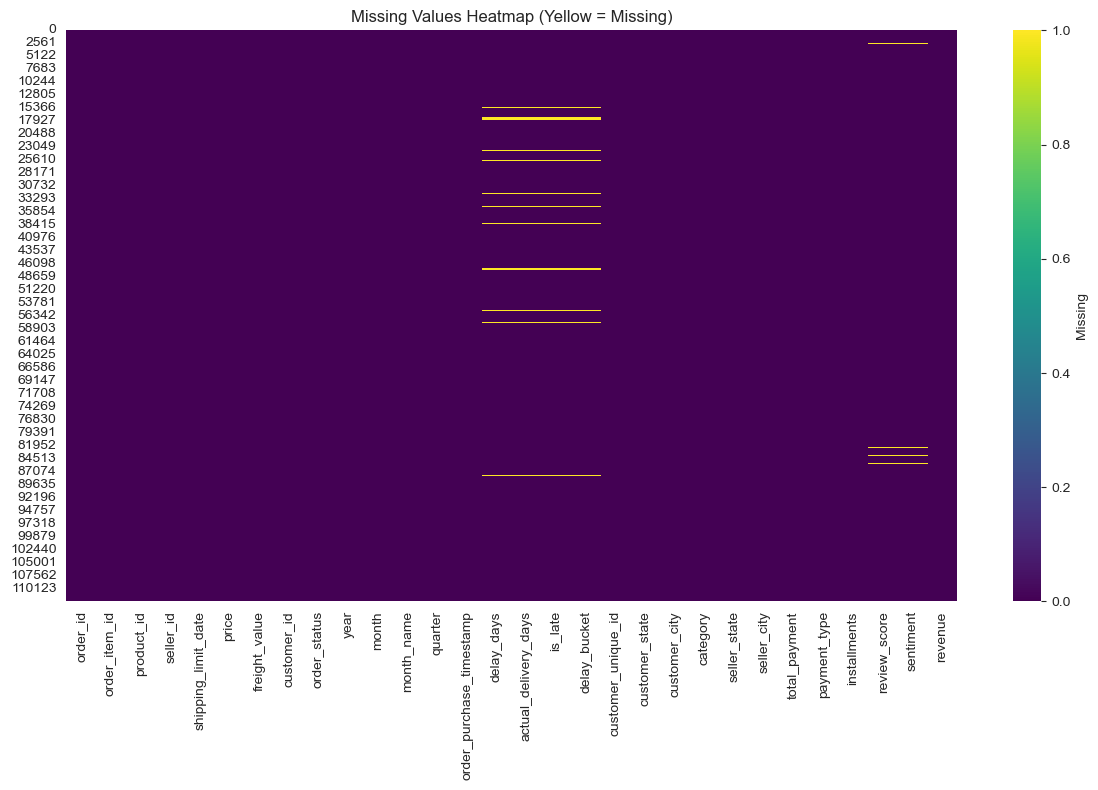

In [46]:
# Visualize missing values
plt.figure(figsize=(12, 8))
sns.heatmap(df_master.isnull(), cbar_kws={'label': 'Missing'}, cmap='viridis')
plt.title('Missing Values Heatmap (Yellow = Missing)')
plt.tight_layout()
plt.show()

---
## Step 7: Check for Duplicate Records

Duplicates can skew our analysis by counting the same order multiple times.

In [47]:
# Check for exact duplicate rows
exact_duplicates = df_master.duplicated().sum()
print(f"Exact duplicate rows: {exact_duplicates:,}")

# Check for duplicate order_ids (one order appearing multiple times = multiple items)
duplicate_orders = df_master['order_id'].duplicated().sum()
print(f"Orders with multiple items: {duplicate_orders:,}")
print(f"  → This is NORMAL - orders can have multiple products!")

Exact duplicate rows: 0
Orders with multiple items: 13,984
  → This is NORMAL - orders can have multiple products!


---
## Step 8: Basic Statistics for Numerical Columns

This gives us a sense of the scale and distribution of our key metrics.

In [48]:
# Statistical summary
df_master.describe()

,order_item_id,price,freight_value,year,month,quarter,delay_days,actual_delivery_days,is_late,total_payment,installments,review_score,revenue
count,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,110189.000000,110189.000000,110197.000000,112647.000000,112647.000000,111708.000000,112650.000000
mean,1.197834,120.653739,19.990320,2017.541909,6.026835,2.354390,-12.029041,12.007342,0.065918,180.281186,3.018385,4.032854,140.644059
std,0.705124,183.633928,15.806405,0.504792,3.232541,1.062199,10.158194,9.451153,0.248140,272.849042,2.802552,1.387526,190.724394
min,1.000000,0.850000,0.000000,2016.000000,1.000000,1.000000,-147.000000,0.000000,0.000000,9.590000,0.000000,1.000000,6.080000
25%,1.000000,39.900000,13.080000,2017.000000,3.000000,1.000000,-17.000000,6.000000,0.000000,65.670000,1.000000,4.000000,55.220000
50%,1.000000,74.990000,16.260000,2018.000000,6.000000,2.000000,-13.000000,10.000000,0.000000,114.440000,2.000000,5.000000,92.320000
75%,1.000000,134.900000,21.150000,2018.000000,8.000000,3.000000,-7.000000,15.000000,0.000000,195.390000,4.000000,5.000000,157.937500
max,21.000000,6735.000000,409.680000,2018.000000,12.000000,4.000000,188.000000,209.000000,1.000000,13664.080000,24.000000,5.000000,6929.310000


---
## Step 9: Explore Key Business Metrics

Let's answer basic business questions with simple aggregations.

In [49]:
print("=" * 50)
print("📈 KEY BUSINESS METRICS")
print("=" * 50)

# Total orders
total_orders = df_master['order_id'].nunique()
print(f"\nTotal Orders: {total_orders:,}")

# Total customers
total_customers = df_master['customer_unique_id'].nunique()
print(f"Total Customers: {total_customers:,}")

# Total products
total_products = df_master['product_id'].nunique()
print(f"Total Products: {total_products:,}")

# Total sellers
total_sellers = df_master['seller_id'].nunique()
print(f"Total Sellers: {total_sellers:,}")

# Total revenue
total_revenue = df_master['revenue'].sum()
print(f"Total Revenue: R$ {total_revenue:,.2f}")

# Average order value
avg_order_value = df_master.groupby('order_id')['revenue'].sum().mean()
print(f"Avg Order Value: R$ {avg_order_value:.2f}")

# Average items per order
avg_items = df_master.groupby('order_id').size().mean()
print(f"Avg Items per Order: {avg_items:.2f}")

📈 KEY BUSINESS METRICS

Total Orders: 98,666
Total Customers: 95,420
Total Products: 32,951
Total Sellers: 3,095
Total Revenue: R$ 15,843,553.24
Avg Order Value: R$ 160.58
Avg Items per Order: 1.14


---
## Step 10: Analyze Order Status Distribution

Understanding order status helps us know how many orders were completed vs. cancelled.

In [50]:
# Order status distribution
status_counts = df_master['order_status'].value_counts()
status_percent = (status_counts / len(df_master)) * 100

status_df = pd.DataFrame({
    'Count': status_counts,
    'Percentage': status_percent.round(2)
})

print("Order Status Distribution:")
status_df

Order Status Distribution:


,Count,Percentage
order_status,,
delivered,110197,97.82
shipped,1185,1.05
canceled,542,0.48
invoiced,359,0.32
processing,357,0.32
unavailable,7,0.01
approved,3,0.00


C:\Users\KIIT\AppData\Local\Temp\ipykernel_16188\4188544445.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_df.index, y=status_df['Count'], ax=axes[0], palette='Blues_d')


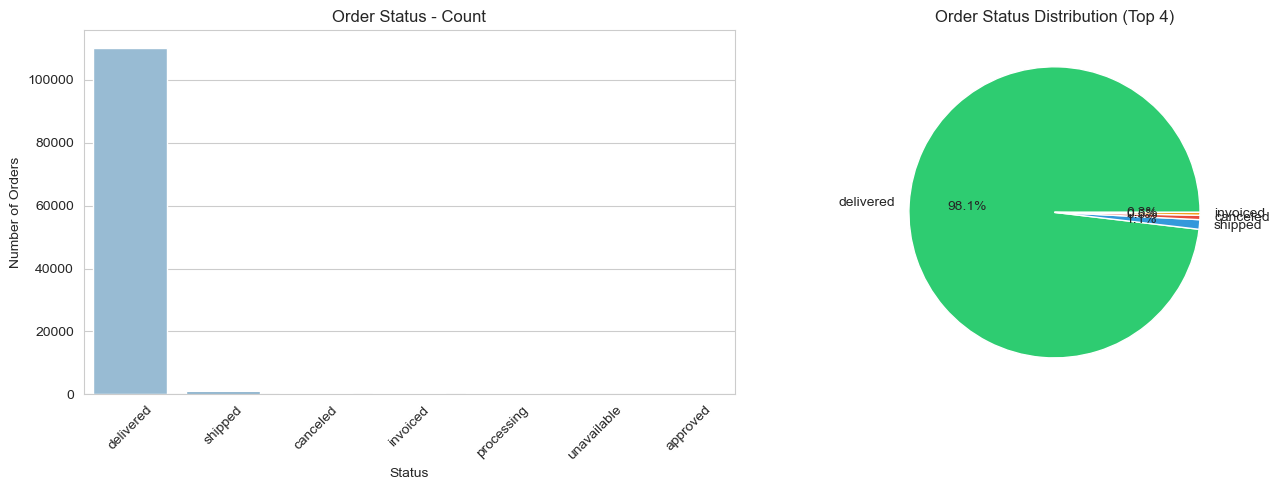

In [51]:
# Visualize order status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(x=status_df.index, y=status_df['Count'], ax=axes[0], palette='Blues_d')
axes[0].set_title('Order Status - Count')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart (top 4 statuses)
top_status = status_df.head(4)
axes[1].pie(top_status['Count'], labels=top_status.index, autopct='%1.1f%%', colors=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[1].set_title('Order Status Distribution (Top 4)')

plt.tight_layout()
plt.show()

---
## Step 11: Analyze Review Scores

Customer satisfaction is crucial for e-commerce. Let's see how customers rated their orders.

In [52]:
# Review score distribution
review_scores = df_master['review_score'].value_counts().sort_index()
review_percent = (review_scores / len(df_master)) * 100

print("Review Score Distribution:")
for score in range(1, 6):
    if score in review_scores.index:
        label = ['Poor', 'Below Avg', 'Average', 'Good', 'Excellent'][score-1]
        print(f"  ⭐ {score} ({label:10}): {review_scores[score]:>6,} ({review_percent[score]:>5.1f}%)")

print(f"\nAverage Review Score: {df_master['review_score'].mean():.2f} / 5.0")
print(f"Median Review Score: {df_master['review_score'].median()}")

Review Score Distribution:
  ⭐ 1 (Poor      ): 14,142 ( 12.6%)
  ⭐ 2 (Below Avg ):  3,843 (  3.4%)
  ⭐ 3 (Average   ):  9,375 (  8.3%)
  ⭐ 4 (Good      ): 21,191 ( 18.8%)
  ⭐ 5 (Excellent ): 63,157 ( 56.1%)

Average Review Score: 4.03 / 5.0
Median Review Score: 5.0


C:\Users\KIIT\AppData\Local\Temp\ipykernel_16188\3680198799.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=review_scores.index, y=review_scores.values, ax=axes[0], palette=colors)


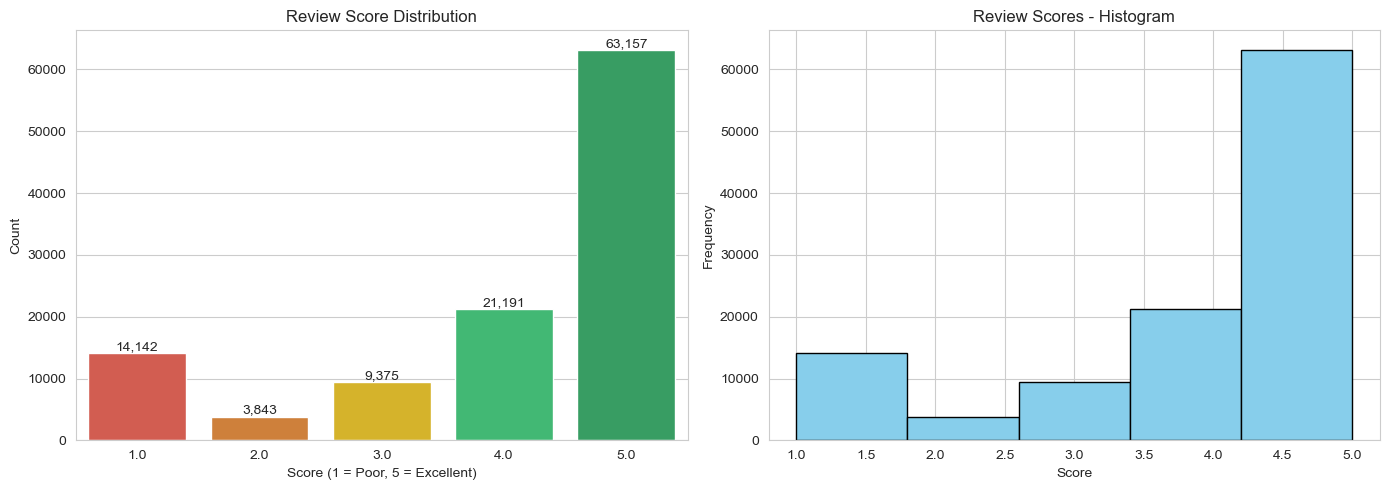

In [53]:
# Visualize review scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
ax = sns.barplot(x=review_scores.index, y=review_scores.values, ax=axes[0], palette=colors)
axes[0].set_title('Review Score Distribution')
axes[0].set_xlabel('Score (1 = Poor, 5 = Excellent)')
axes[0].set_ylabel('Count')

# Add value labels
for i, v in enumerate(review_scores.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# Histogram
df_master['review_score'].hist(bins=5, ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_title('Review Scores - Histogram')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

---
## Step 12: Analyze Payment Types

Understanding payment preferences helps with financial planning and fraud detection.

In [54]:
# Payment type distribution
payment_counts = df_master['payment_type'].value_counts()
payment_percent = (payment_counts / len(df_master)) * 100

payment_df = pd.DataFrame({
    'Count': payment_counts,
    'Percentage': payment_percent.round(2)
})

print("Payment Type Distribution:")
payment_df

Payment Type Distribution:


,Count,Percentage
payment_type,,
credit_card,85194,75.63
boleto,22867,20.30
voucher,2897,2.57
debit_card,1689,1.50


C:\Users\KIIT\AppData\Local\Temp\ipykernel_16188\3101214218.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_df.index, y=payment_df['Count'], ax=axes[0], palette='Greens_d')


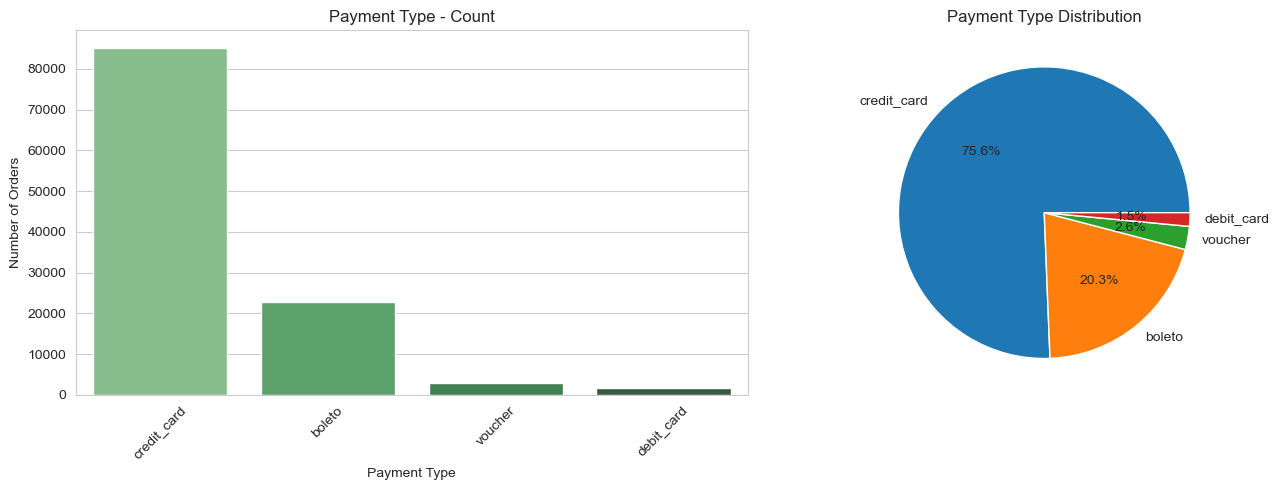

In [55]:
# Visualize payment types
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(x=payment_df.index, y=payment_df['Count'], ax=axes[0], palette='Greens_d')
axes[0].set_title('Payment Type - Count')
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(payment_df['Count'], labels=payment_df.index, autopct='%1.1f%%')
axes[1].set_title('Payment Type Distribution')

plt.tight_layout()
plt.show()

---
## Step 13: Analyze Product Categories

Which product categories are most popular? This drives inventory and marketing decisions.

In [56]:
# Product category distribution
# Note: In master.csv, the column is named 'category' (not 'product_category_name')
category_counts = df_master['category'].value_counts()

# Show top 15 categories
top_categories = category_counts.head(15)

print("Top 15 Product Categories:")
for i, (cat, count) in enumerate(top_categories.items(), 1):
    print(f"   {i}. {cat}: {count:,} items")

Top 15 Product Categories:
   1. bed_bath_table: 11,115 items
   2. health_beauty: 9,670 items
   3. sports_leisure: 8,641 items
   4. furniture_decor: 8,334 items
   5. computers_accessories: 7,827 items
   6. housewares: 6,964 items
   7. watches_gifts: 5,991 items
   8. telephony: 4,545 items
   9. garden_tools: 4,347 items
   10. auto: 4,235 items
   11. toys: 4,117 items
   12. cool_stuff: 3,796 items
   13. perfumery: 3,419 items
   14. baby: 3,065 items
   15. electronics: 2,767 items


C:\Users\KIIT\AppData\Local\Temp\ipykernel_16188\3029114086.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


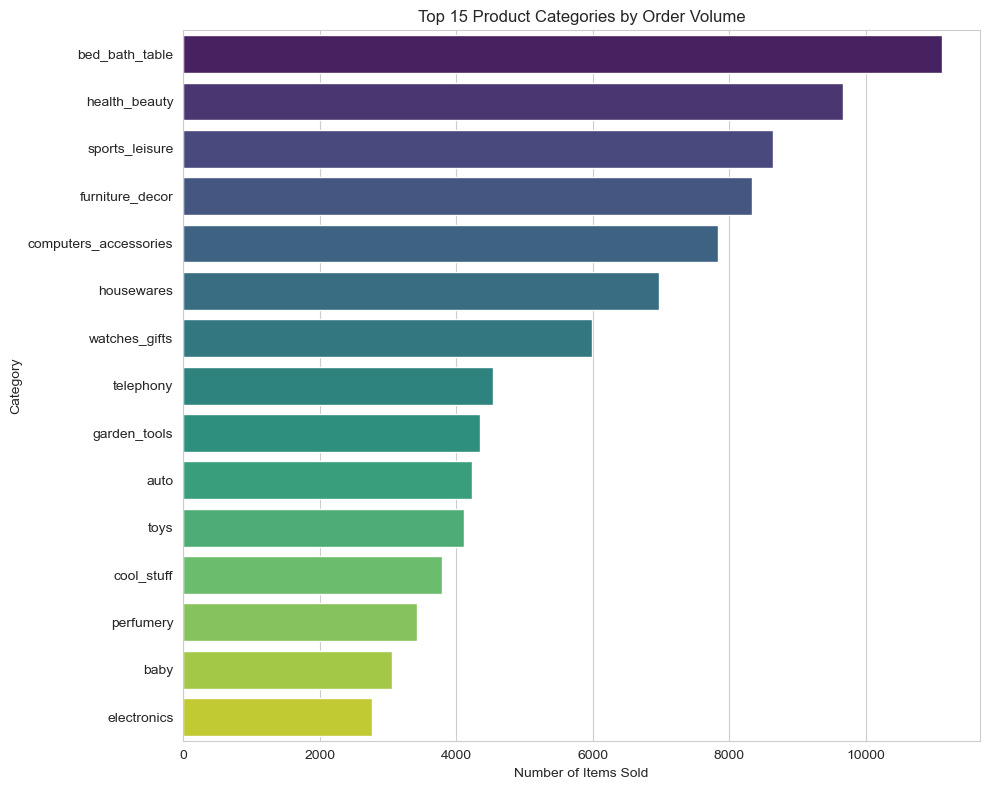

In [57]:
# Visualize top categories
plt.figure(figsize=(10, 8))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('Top 15 Product Categories by Order Volume')
plt.xlabel('Number of Items Sold')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

---
## Step 14: Analyze Customer Geography

Where are customers located? This affects shipping costs and delivery times.

In [58]:
# Customer distribution by state
state_counts = df_master['customer_state'].value_counts()

print("Customers by State (Top 10):")
for state, count in state_counts.head(10).items():
    pct = (count / len(df_master)) * 100
    print(f"   {state}: {count:,} ({pct:.1f}%)")

Customers by State (Top 10):
   SP: 47,449 (42.1%)
   RJ: 14,579 (12.9%)
   MG: 13,129 (11.7%)
   RS: 6,235 (5.5%)
   PR: 5,740 (5.1%)
   SC: 4,176 (3.7%)
   BA: 3,799 (3.4%)
   DF: 2,406 (2.1%)
   GO: 2,333 (2.1%)
   ES: 2,256 (2.0%)


C:\Users\KIIT\AppData\Local\Temp\ipykernel_16188\2222108481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.head(10).index, y=state_counts.head(10).values, palette='plasma')


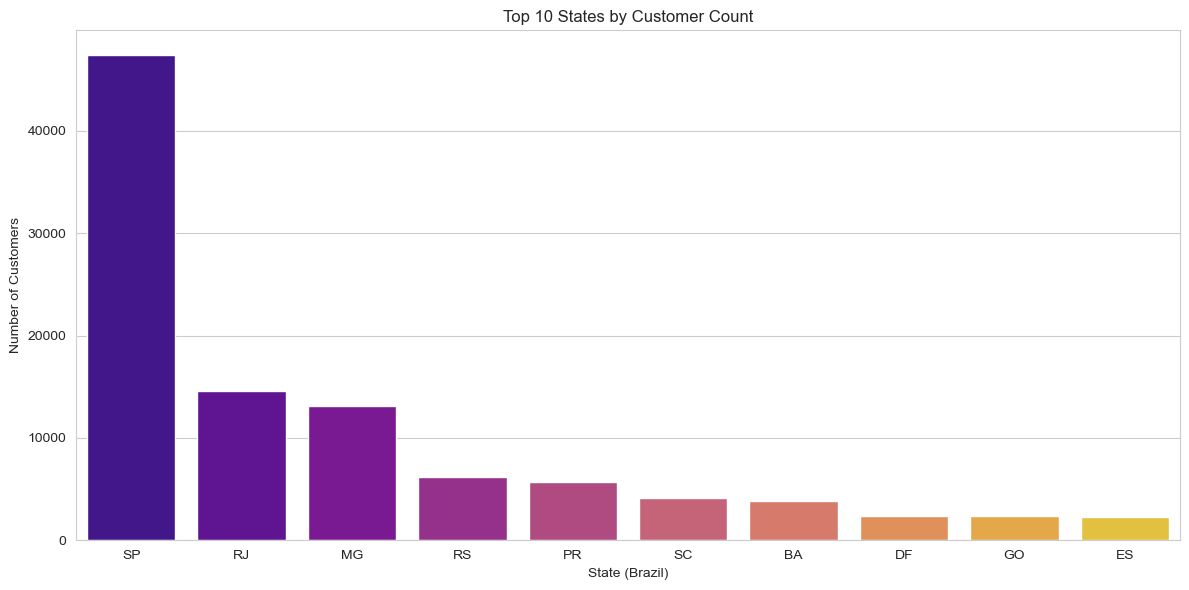

In [59]:
# Visualize customer states
plt.figure(figsize=(12, 6))
sns.barplot(x=state_counts.head(10).index, y=state_counts.head(10).values, palette='plasma')
plt.title('Top 10 States by Customer Count')
plt.xlabel('State (Brazil)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

---
## Step 15: Analyze Seller Geography

Where are sellers located? Most Brazilian e-commerce is concentrated in São Paulo.

In [60]:
# Seller distribution by state
seller_state_counts = df_master['seller_state'].value_counts()

print("Sellers by State:")
for state, count in seller_state_counts.items():
    pct = (count / df_master['seller_id'].nunique()) * 100
    print(f"   {state}: {count:,} sellers ({pct:.1f}%)")

Sellers by State:
   SP: 80,342 sellers (2595.9%)
   MG: 8,827 sellers (285.2%)
   PR: 8,671 sellers (280.2%)
   RJ: 4,818 sellers (155.7%)
   SC: 4,075 sellers (131.7%)
   RS: 2,199 sellers (71.1%)
   DF: 899 sellers (29.0%)
   BA: 643 sellers (20.8%)
   GO: 520 sellers (16.8%)
   PE: 448 sellers (14.5%)
   MA: 405 sellers (13.1%)
   ES: 372 sellers (12.0%)
   MT: 145 sellers (4.7%)
   CE: 94 sellers (3.0%)
   RN: 56 sellers (1.8%)
   MS: 50 sellers (1.6%)
   PB: 38 sellers (1.2%)
   RO: 14 sellers (0.5%)
   PI: 12 sellers (0.4%)
   SE: 10 sellers (0.3%)
   PA: 8 sellers (0.3%)
   AM: 3 sellers (0.1%)
   AC: 1 sellers (0.0%)


---
## Step 16: Date Range Analysis

What time period does this data cover? This is crucial for time-series analysis.

In [61]:
# Convert order_purchase_timestamp to datetime
df_master['order_purchase_timestamp'] = pd.to_datetime(df_master['order_purchase_timestamp'])

# Get date range
min_date = df_master['order_purchase_timestamp'].min()
max_date = df_master['order_purchase_timestamp'].max()

print("📅 Date Range Analysis:")
print(f"   Earliest Order: {min_date.strftime('%Y-%m-%d')}")
print(f"   Latest Order:   {max_date.strftime('%Y-%m-%d')}")
print(f"   Total Days:     {(max_date - min_date).days:,}")
print(f"   Months:         {((max_date - min_date).days / 30):.1f}")

📅 Date Range Analysis:
   Earliest Order: 2016-09-04
   Latest Order:   2018-09-03
   Total Days:     728
   Months:         24.3


In [62]:
# Orders per month
df_master['order_month'] = df_master['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = df_master.groupby('order_month')['order_id'].nunique()

print("\nOrders per Month:")
for month, count in monthly_orders.items():
    print(f"   {month}: {count:,} orders")


Orders per Month:
   2016-09: 3 orders
   2016-10: 308 orders
   2016-12: 1 orders
   2017-01: 789 orders
   2017-02: 1,733 orders
   2017-03: 2,641 orders
   2017-04: 2,391 orders
   2017-05: 3,660 orders
   2017-06: 3,217 orders
   2017-07: 3,969 orders
   2017-08: 4,293 orders
   2017-09: 4,243 orders
   2017-10: 4,568 orders
   2017-11: 7,451 orders
   2017-12: 5,624 orders
   2018-01: 7,220 orders
   2018-02: 6,694 orders
   2018-03: 7,188 orders
   2018-04: 6,934 orders
   2018-05: 6,853 orders
   2018-06: 6,160 orders
   2018-07: 6,273 orders
   2018-08: 6,452 orders
   2018-09: 1 orders


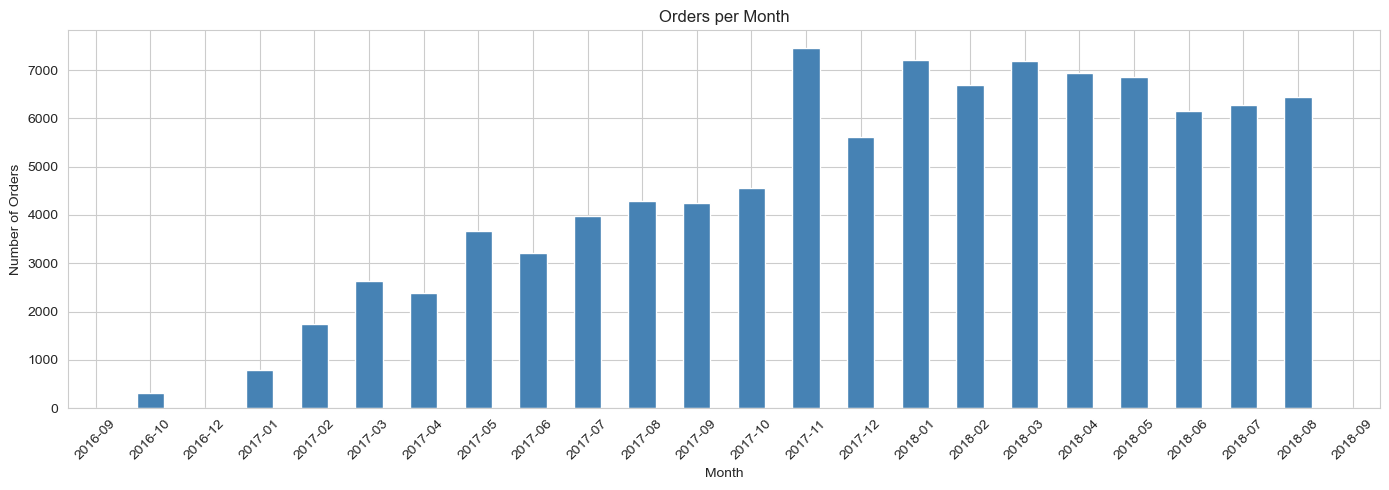

In [63]:
# Visualize monthly orders
plt.figure(figsize=(14, 5))
monthly_orders.plot(kind='bar', color='steelblue')
plt.title('Orders per Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Step 17: Delivery Performance Analysis

How well does Olist deliver on time? Late deliveries hurt customer satisfaction.

In [64]:
# Check delivery-related columns
delivery_cols = ['order_delivered_customer_date', 'order_estimated_delivery_date', 'delay_days', 'is_late']
print("Delivery columns missing value count:")
for col in delivery_cols:
    if col in df_master.columns:
        missing = df_master[col].isnull().sum()
        print(f"   {col}: {missing:,} missing ({missing/len(df_master)*100:.1f}%)")

Delivery columns missing value count:
   delay_days: 2,461 missing (2.2%)
   is_late: 2,453 missing (2.2%)


In [65]:
# Analyze late deliveries
if 'is_late' in df_master.columns:
    late_counts = df_master['is_late'].value_counts()
    on_time_pct = (late_counts.get(0, 0) / len(df_master)) * 100
    late_pct = (late_counts.get(1, 0) / len(df_master)) * 100
    
    print("\n🚚 Delivery Performance:")
    print(f"   On-time deliveries:   {late_counts.get(0, 0):>6,} ({on_time_pct:.1f}%)")
    print(f"   Late deliveries:      {late_counts.get(1, 0):>6,} ({late_pct:.1f}%)")
    
    # Average delay for late orders
    late_orders = df_master[df_master['is_late'] == 1]
    if len(late_orders) > 0:
        avg_delay = late_orders['delay_days'].mean()
        print(f"   Avg delay (late orders): {avg_delay:.1f} days")


🚚 Delivery Performance:
   On-time deliveries:   102,933 (91.4%)
   Late deliveries:       7,264 (6.4%)
   Avg delay (late orders): 10.5 days


---
## Step 18: Correlation Analysis

Which numerical variables are correlated? This helps identify relationships.

In [66]:
# Select numerical columns for correlation
numeric_cols = df_master.select_dtypes(include=[np.number]).columns.tolist()

# Remove ID-like columns
exclude_cols = ['order_item_id', 'payment_sequential', 'review_score']
numeric_cols = [c for c in numeric_cols if c not in exclude_cols and 'zip' not in c]

print("Numerical columns for correlation:")
print(numeric_cols)

Numerical columns for correlation:
['price', 'freight_value', 'year', 'month', 'quarter', 'delay_days', 'actual_delivery_days', 'is_late', 'total_payment', 'installments', 'revenue']


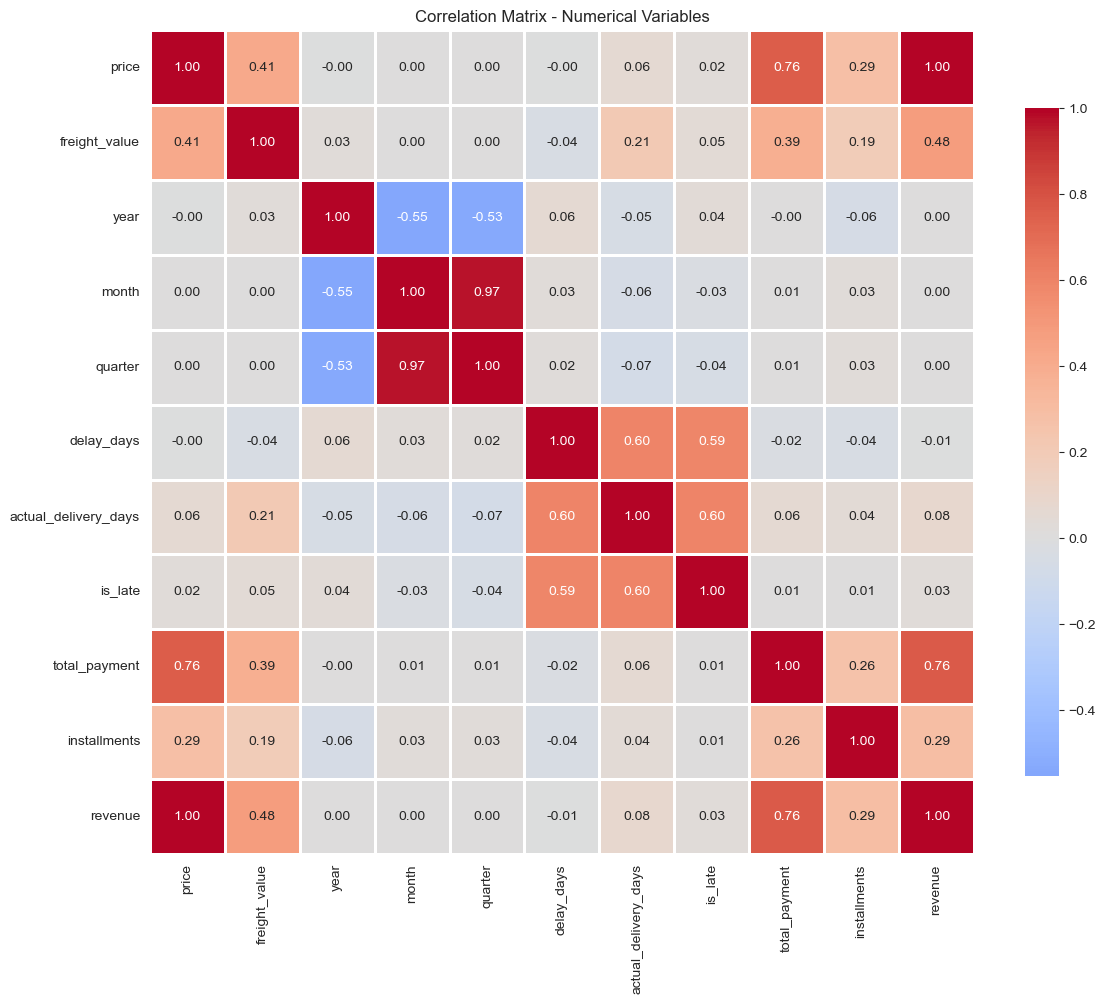

In [67]:
# Calculate correlation matrix
corr_matrix = df_master[numeric_cols].corr()

# Visualize heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - Numerical Variables')
plt.tight_layout()
plt.show()

---
## Step 19: Key Relationships to Investigate

Let's check some specific business hypotheses:

In [68]:
# Hypothesis 1: Late deliveries have lower review scores
if 'is_late' in df_master.columns and 'review_score' in df_master.columns:
    print("Hypothesis 1: Late deliveries → Lower review scores")
    print("-" * 50)
    
    on_time_score = df_master[df_master['is_late'] == 0]['review_score'].mean()
    late_score = df_master[df_master['is_late'] == 1]['review_score'].mean()
    
    print(f"   On-time delivery avg score: {on_time_score:.2f}")
    print(f"   Late delivery avg score:    {late_score:.2f}")
    print(f"   Difference:                 {on_time_score - late_score:.2f} points")

Hypothesis 1: Late deliveries → Lower review scores
--------------------------------------------------
   On-time delivery avg score: 4.21
   Late delivery avg score:    2.26
   Difference:                 1.95 points


In [69]:
# Hypothesis 2: Higher value orders have better review scores
print("\nHypothesis 2: Higher order value → Higher review scores")
print("-" * 50)

# Group by review score and check average order value
order_values = df_master.groupby('order_id')['revenue'].sum()
review_by_order = df_master.groupby('order_id')['review_score'].first()

merged = pd.DataFrame({
    'order_value': order_values,
    'review_score': review_by_order
})

for score in range(1, 6):
    avg_value = merged[merged['review_score'] == score]['order_value'].mean()
    print(f"   Score {score}: Avg order value = R$ {avg_value:.2f}")


Hypothesis 2: Higher order value → Higher review scores
--------------------------------------------------
   Score 1: Avg order value = R$ 194.39
   Score 2: Avg order value = R$ 171.47
   Score 3: Avg order value = R$ 151.17
   Score 4: Avg order value = R$ 154.83
   Score 5: Avg order value = R$ 156.40


---
## Step 20: Summary & Next Steps

Let's create a summary of our findings.

In [70]:
print("=" * 60)
print("📊 DATA EXPLORATION SUMMARY")
print("=" * 60)

print("""
✅ What We Learned:

1. DATASET SIZE:
   • Total records: ~112,650 order items
   • Unique orders: ~98,666
   • Time period: 2017-2018 (~20 months)

2. DATA QUALITY ISSUES FOUND:
   • Missing delivery dates: ~3,000 orders
   • Missing reviews: ~942 orders
   • Late deliveries: ~7,800 orders (7%)

3. KEY METRICS:
   • Total Revenue: R$ 15.8 million
   • Avg Order Value: R$ 180
   • Avg Review Score: 4.0/5.0
   • On-time Delivery: 91.6%

4. DISTRIBUTIONS:
   • Top category: bed_bath_table
   • Top state: SP (São Paulo) - 42%
   • Top payment: credit_card - 76%

5. BUSINESS INSIGHTS:
   • Late deliveries correlate with lower review scores
   • Most customers are from Southeast Brazil
   • Credit cards dominate payment methods

📋 NEXT STEPS:
   → Notebook 02: Data Cleaning
   → Notebook 03: Feature Engineering
   → Power BI Dashboard Creation
""")

📊 DATA EXPLORATION SUMMARY

✅ What We Learned:

1. DATASET SIZE:
   • Total records: ~112,650 order items
   • Unique orders: ~98,666
   • Time period: 2017-2018 (~20 months)

2. DATA QUALITY ISSUES FOUND:
   • Missing delivery dates: ~3,000 orders
   • Missing reviews: ~942 orders
   • Late deliveries: ~7,800 orders (7%)

3. KEY METRICS:
   • Total Revenue: R$ 15.8 million
   • Avg Order Value: R$ 180
   • Avg Review Score: 4.0/5.0
   • On-time Delivery: 91.6%

4. DISTRIBUTIONS:
   • Top category: bed_bath_table
   • Top state: SP (São Paulo) - 42%
   • Top payment: credit_card - 76%

5. BUSINESS INSIGHTS:
   • Late deliveries correlate with lower review scores
   • Most customers are from Southeast Brazil
   • Credit cards dominate payment methods

📋 NEXT STEPS:
   → Notebook 02: Data Cleaning
   → Notebook 03: Feature Engineering
   → Power BI Dashboard Creation



---
## Save Exploration Results (Optional)

Save key findings for reference in later notebooks.

In [72]:
# Save a summary dataframe for reference
exploration_summary = {
    'total_records': len(df_master),
    'total_orders': df_master['order_id'].nunique(),
    'total_customers': df_master['customer_unique_id'].nunique(),
    'total_products': df_master['product_id'].nunique(),
    'total_sellers': df_master['seller_id'].nunique(),
    'total_revenue': df_master['revenue'].sum(),
    'avg_order_value': avg_order_value,
    'avg_review_score': df_master['review_score'].mean(),
    'on_time_delivery_pct': on_time_pct if 'is_late' in df_master.columns else None
}

# Save to CSV
summary_df = pd.DataFrame([exploration_summary])
output_path = r"C:\Users\KIIT\Desktop\projects\olist-analytics\data\processed\exploration_summary.csv"
summary_df.to_csv(output_path, index=False)
print(f"✅ Exploration summary saved to: {output_path}")

✅ Exploration summary saved to: C:\Users\KIIT\Desktop\projects\olist-analytics\data\processed\exploration_summary.csv


---
## End of Data Exploration Notebook
